# Seller Marketing Funnel и ценность привлечённых продавцов

## Цель анализа

Цель этого ноутбука — проанализировать воронку привлечения продавцов Olist и оценить каналы не только по конверсии маркетинговых лидов в закрытые сделки, но и по последующей ценности привлечённых продавцов.

Базовая воронка анализа:

**MQL → Closed Deal → Seller with Orders → Seller GMV**

Такой подход позволяет отделить формальное закрытие сделки от фактической активации продавца на маркетплейсе.

Важно учитывать ограничения данных:

- в датасете отсутствуют расходы на маркетинговые каналы;
- поэтому нельзя рассчитать настоящий CAC;
- данные позволяют сравнить каналы по конверсии, скорости закрытия сделки, активации продавцов и последующему GMV;
- Marketing Funnel описывает привлечение продавцов, а не покупательскую воронку.

In [1]:
from pathlib import Path

import pandas as pd

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

mql_path = RAW_DATA_DIR / "olist_marketing_qualified_leads_dataset.csv"
closed_deals_path = RAW_DATA_DIR / "olist_closed_deals_dataset.csv"

print(mql_path)
print(closed_deals_path)

..\data\raw\olist_marketing_qualified_leads_dataset.csv
..\data\raw\olist_closed_deals_dataset.csv


In [4]:
mql = pd.read_csv(
    mql_path,
    parse_dates=["first_contact_date"],
)

closed_deals = pd.read_csv(
    closed_deals_path,
    parse_dates=["won_date"],
)

In [5]:
print(f"mql: {mql.shape[0]:,} строк, {mql.shape[1]} колонок")
print(
    f"closed_deals: {closed_deals.shape[0]:,} строк, "
    f"{closed_deals.shape[1]} колонок"
)

display(mql.head())
display(closed_deals.head())

mql: 8,000 строк, 4 колонок
closed_deals: 842 строк, 14 колонок


,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.00
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.00
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.00
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.00
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.00


## Проверка структуры и ключей таблиц

Перед построением воронки необходимо определить уровень детализации таблиц и проверить уникальность ключей.

Ожидаемая логика:

- `mql` — одна строка на маркетинговый лид;
- `closed_deals` — одна строка на закрытую сделку;
- связь между таблицами выполняется по `mql_id`;
- `seller_id` связывает закрытую сделку с продавцом маркетплейса.

Проверка ключей нужна, чтобы избежать размножения строк при последующих объединениях.

In [6]:
print("Структура таблицы mql:")
mql.info()

print("\nСтруктура таблицы closed_deals:")
closed_deals.info()

Структура таблицы mql:
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   mql_id              8000 non-null   str           
 1   first_contact_date  8000 non-null   datetime64[us]
 2   landing_page_id     8000 non-null   str           
 3   origin              7940 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 250.1 KB

Структура таблицы closed_deals:
<class 'pandas.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   mql_id                         842 non-null    str           
 1   seller_id                      842 non-null    str           
 2   sdr_id                         842 non-null    str           
 3   sr_id                 

In [7]:
key_check = pd.DataFrame(
    {
        "table": ["mql", "closed_deals", "closed_deals"],
        "key": ["mql_id", "mql_id", "seller_id"],
        "rows": [
            len(mql),
            len(closed_deals),
            len(closed_deals),
        ],
        "non_null_values": [
            mql["mql_id"].notna().sum(),
            closed_deals["mql_id"].notna().sum(),
            closed_deals["seller_id"].notna().sum(),
        ],
        "unique_values": [
            mql["mql_id"].nunique(),
            closed_deals["mql_id"].nunique(),
            closed_deals["seller_id"].nunique(),
        ],
        "duplicates": [
            mql["mql_id"].duplicated().sum(),
            closed_deals["mql_id"].duplicated().sum(),
            closed_deals["seller_id"].duplicated().sum(),
        ],
    }
)

key_check

,table,key,rows,non_null_values,unique_values,duplicates
0,mql,mql_id,8000,8000,8000,0
1,closed_deals,mql_id,842,842,842,0
2,closed_deals,seller_id,842,842,842,0


### Вывод по структуре таблиц

Таблица `mql` содержит 8 000 уникальных маркетинговых лидов, а `closed_deals` — 842 уникальные закрытые сделки.

Ключ `mql_id` уникален в обеих таблицах, а `seller_id` уникален в `closed_deals`. Это означает, что один маркетинговый лид может привести максимум к одной закрытой сделке и одному привлечённому продавцу.

Таблицы можно безопасно объединять по `mql_id` без размножения строк. Для построения полной воронки необходимо использовать `left join` от `mql` к `closed_deals`, чтобы сохранить не только закрытые сделки, но и лиды, которые не конвертировались.


In [8]:
mql_ids = set(mql["mql_id"])
closed_deal_mql_ids = set(closed_deals["mql_id"])

print(
    "Closed deals без соответствующего MQL:",
    len(closed_deal_mql_ids - mql_ids),
)

print(
    "MQL без закрытой сделки:",
    len(mql_ids - closed_deal_mql_ids),
)

print(
    "Базовая конверсия MQL → Closed Deal:",
    f"{len(closed_deals) / len(mql):.2%}",
)

Closed deals без соответствующего MQL: 0
MQL без закрытой сделки: 7158
Базовая конверсия MQL → Closed Deal: 10.53%


### Вывод по связи таблиц

Все 842 закрытые сделки имеют соответствующий `mql_id` в таблице маркетинговых лидов. Из 8 000 MQL не завершились сделкой 7 158 лидов.

Базовая конверсия:

**MQL → Closed Deal = 10,53%**

Эта метрика показывает только долю лидов, завершившихся формальной сделкой. Она ещё не учитывает, начал ли привлечённый продавец получать заказы и какой GMV он впоследствии принёс маркетплейсу.


In [9]:
funnel_base = mql.merge(
    closed_deals,
    on="mql_id",
    how="left",
    validate="one_to_one",
)

funnel_base["is_closed_deal"] = funnel_base["seller_id"].notna()

funnel_base["days_to_close"] = (
    funnel_base["won_date"] - funnel_base["first_contact_date"]
).dt.total_seconds() / 86_400

In [10]:
print(f"Строк в funnel_base: {len(funnel_base):,}")
print(f"Уникальных mql_id: {funnel_base['mql_id'].nunique():,}")
print(f"Дубликатов mql_id: {funnel_base['mql_id'].duplicated().sum():,}")

print(
    "Закрытых сделок:",
    funnel_base["is_closed_deal"].sum(),
)

print(
    "Конверсия MQL → Closed Deal:",
    f"{funnel_base['is_closed_deal'].mean():.2%}",
)

print(
    "Сделок с отрицательным days_to_close:",
    funnel_base["days_to_close"].lt(0).sum(),
)

Строк в funnel_base: 8,000
Уникальных mql_id: 8,000
Дубликатов mql_id: 0
Закрытых сделок: 842
Конверсия MQL → Closed Deal: 10.53%
Сделок с отрицательным days_to_close: 1


### Вывод по базовой воронке

После объединения таблиц витрина `funnel_base` содержит 8 000 строк — по одной строке на каждый маркетинговый лид.

Количество строк и уникальных `mql_id` совпадает, дубликатов нет. Это подтверждает, что объединение выполнено корректно и не привело к размножению данных.

Из 8 000 лидов 842 завершились закрытой сделкой, поэтому конверсия `MQL → Closed Deal` составляет 10,53%.

Обнаружена одна сделка с отрицательной длительностью закрытия: `won_date` находится раньше `first_contact_date`. Этот случай необходимо отдельно проверить как возможную ошибку или особенность исходных данных.


In [11]:
negative_close_time = funnel_base.loc[
    funnel_base["days_to_close"] < 0,
    [
        "mql_id",
        "first_contact_date",
        "won_date",
        "days_to_close",
        "origin",
        "seller_id",
        "business_segment",
        "lead_type",
    ],
]

negative_close_time

,mql_id,first_contact_date,won_date,days_to_close,origin,seller_id,business_segment,lead_type
6357,b91cf8812365f50ff4bda4bcd6206b05,2018-03-08,2018-03-06 19:38:55,-1.18,organic_search,5e063e85d44b0f5c3e6ec3131103a57e,health_beauty,online_big


In [12]:
days_to_close_summary = (
    funnel_base.loc[
        funnel_base["is_closed_deal"] & funnel_base["days_to_close"].ge(0),
        "days_to_close",
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
    .to_frame("days_to_close")
)

days_to_close_summary

,days_to_close
count,841.00
mean,49.16
std,75.36
min,0.08
25%,5.86
50%,14.72
75%,55.12
90%,162.67
95%,210.88
max,427.55


### Вывод по скорости закрытия сделок

Для 841 корректной закрытой сделки медианное время от первого контакта до закрытия составляет 14,72 дня.

Среднее время закрытия значительно выше — 49,16 дня. Это связано с правосторонней асимметрией распределения: часть сделок закрывалась более 160–210 дней, а максимальное значение достигало 427,55 дня.

Поэтому для сравнения скорости работы каналов и сегментов основной метрикой будет медианное количество дней до закрытия сделки.

Одна сделка имеет отрицательный срок закрытия `-1,18 дня`. Вероятно, это ошибка дат или особенность регистрации контакта. Сделка сохраняется при расчёте конверсии, но исключается из анализа длительности закрытия.


In [13]:
funnel_base["days_to_close_valid"] = funnel_base["days_to_close"].where(
    funnel_base["days_to_close"].ge(0)
)

print(
    "Корректных значений days_to_close_valid:",
    funnel_base["days_to_close_valid"].notna().sum(),
)

print(
    "Медианное время закрытия:",
    f"{funnel_base['days_to_close_valid'].median():.2f} дня",
)

Корректных значений days_to_close_valid: 841
Медианное время закрытия: 14.72 дня


In [14]:
categorical_columns = [
    "origin",
    "business_segment",
    "lead_type",
    "business_type",
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(
        funnel_base[column]
        .value_counts(dropna=False)
        .head(20)
    )


origin:
origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
NaN                    60
Name: count, dtype: int64

business_segment:
business_segment
NaN                                7159
home_decor                          105
health_beauty                        93
car_accessories                      77
household_utilities                  71
construction_tools_house_garden      69
audio_video_electronics              64
computers                            34
pet                                  30
food_supplement                      28
food_drink                           26
sports_leisure                       25
bed_bath_table                       22
bags_backpacks                       22
toys                                 20
fashion_accessories                 

### Особенности категориальных признаков

Канал привлечения `origin` содержится в таблице маркетинговых лидов и доступен как для закрытых, так и для незакрытых лидов. Поэтому по этому признаку можно корректно сравнивать количество MQL и конверсию в закрытую сделку.

Признаки `business_segment`, `lead_type` и `business_type` присутствуют только в таблице `closed_deals`. Пропуски в этих колонках у незакрытых лидов являются ожидаемым результатом объединения, а не ошибкой качества данных.

Следовательно, эти признаки нельзя использовать для расчёта конверсии `MQL → Closed Deal`, поскольку их значения неизвестны для лидов, которые не завершились сделкой. Они будут использоваться для анализа профиля, активации и последующей ценности уже привлечённых продавцов.


In [15]:
funnel_base["origin_group"] = funnel_base["origin"].fillna("missing")

funnel_base["origin_group"].value_counts(dropna=False)

origin_group
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
missing                60
Name: count, dtype: int64

In [16]:
origin_funnel = (
    funnel_base
    .groupby("origin_group", as_index=False)
    .agg(
        mql_count=("mql_id", "count"),
        closed_deals=("is_closed_deal", "sum"),
        median_days_to_close=("days_to_close_valid", "median"),
    )
)

origin_funnel["conversion_rate"] = (
    origin_funnel["closed_deals"] / origin_funnel["mql_count"]
)

origin_funnel = origin_funnel.sort_values(
    "mql_count",
    ascending=False,
)

origin_funnel

,origin_group,mql_count,closed_deals,median_days_to_close,conversion_rate
4,organic_search,2296,271,15.25,0.12
7,paid_search,1586,195,15.67,0.12
9,social,1350,75,30.56,0.06
10,unknown,1099,179,11.83,0.16
0,direct_traffic,499,56,10.58,0.11
2,email,493,15,21.12,0.03
8,referral,284,24,19.37,0.08
5,other,150,4,9.56,0.03
1,display,118,6,9.17,0.05
6,other_publicities,65,3,35.79,0.05


### Вывод по каналам привлечения

Наибольший объём MQL дают каналы `organic_search`, `paid_search` и `social`.

`organic_search` и `paid_search` показывают сопоставимую конверсию около 12% и формируют более половины всех закрытых сделок. Это делает их основными масштабируемыми каналами seller acquisition в доступных данных.

Канал `social` генерирует значительный объём лидов, но его конверсия составляет около 6%, а медианное время закрытия сделки превышает 30 дней. Это может указывать на более низкое качество или меньшую готовность лидов к подключению.

`direct_traffic` имеет конверсию около 11% и относительно быстрое медианное закрытие — около 11 дней.

Категории `unknown` и `missing` показывают высокую конверсию, однако их нельзя напрямую интерпретировать как эффективные маркетинговые каналы. Они отражают проблемы или особенности атрибуции источника. Особенно осторожно следует оценивать `missing`, поскольку группа включает только 60 лидов.

Таким образом, канал следует оценивать одновременно по трём параметрам:

* объёму привлечённых лидов;
* конверсии в закрытую сделку;
* скорости закрытия сделки.

Высокая конверсия на небольшой выборке ещё не означает, что канал является лучшим для масштабирования.


In [17]:
import matplotlib.pyplot as plt

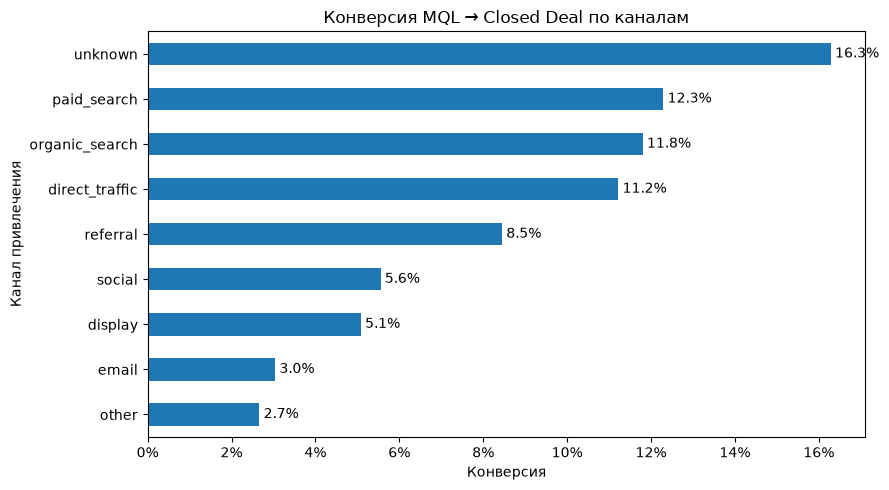

In [18]:
origin_conversion_plot = (
    origin_funnel
    .query("mql_count >= 100")
    .sort_values("conversion_rate")
)

ax = origin_conversion_plot.plot(
    x="origin_group",
    y="conversion_rate",
    kind="barh",
    figsize=(9, 5),
    legend=False,
)

ax.set_title("Конверсия MQL → Closed Deal по каналам")
ax.set_xlabel("Конверсия")
ax.set_ylabel("Канал привлечения")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:.1%}"
            for value in origin_conversion_plot["conversion_rate"]
        ],
        padding=3,
    )

plt.tight_layout()
plt.show()

### Интерпретация конверсии по каналам

Среди каналов с достаточным количеством наблюдений наиболее высокую конверсию показывает группа `unknown` — 16,3%. Однако эта категория не является конкретным каналом привлечения и отражает отсутствие корректной атрибуции, поэтому её нельзя использовать как основание для перераспределения маркетингового бюджета.

Среди идентифицированных каналов лучшие результаты показывают:

- `paid_search` — 12,3%;
- `organic_search` — 11,8%;
- `direct_traffic` — 11,2%.

Канал `social` обеспечивает большой объём лидов, но конвертирует в закрытую сделку только 5,6% MQL. `email` и `other` имеют ещё более низкую конверсию.

При этом оценка только по конверсии недостаточна: далее необходимо проверить, начали ли привлечённые продавцы получать заказы и какой GMV они принесли после подключения к маркетплейсу.

## Связь привлечённых продавцов с заказами

Закрытая сделка ещё не означает, что продавец начал работать на маркетплейсе.

Чтобы оценить фактическую ценность привлечённых продавцов, необходимо связать `seller_id` из таблицы закрытых сделок с товарными позициями в `order_items`.

Для расчёта используются:

- `order_items` — продавец и стоимость каждой товарной позиции;
- `orders` — статус заказа и дата покупки.

Seller GMV будет рассчитываться как сумма `price` по доставленным заказам. Таблицы сначала проверяются на уровне ключей, чтобы избежать задвоения показателей.

In [19]:
order_items_path = RAW_DATA_DIR / "olist_order_items_dataset.csv"
orders_path = RAW_DATA_DIR / "olist_orders_dataset.csv"

order_items = pd.read_csv(
    order_items_path,
    parse_dates=["shipping_limit_date"],
)

orders = pd.read_csv(
    orders_path,
    parse_dates=["order_purchase_timestamp"],
)

In [20]:
print(
    f"order_items: {len(order_items):,} строк, "
    f"{order_items['order_id'].nunique():,} заказов, "
    f"{order_items['seller_id'].nunique():,} продавцов"
)

print(
    f"orders: {len(orders):,} строк, "
    f"{orders['order_id'].nunique():,} уникальных заказов"
)

print(
    "Дубликатов ключа order_id + order_item_id:",
    order_items.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum(),
)

print(
    "Дубликатов order_id в orders:",
    orders["order_id"].duplicated().sum(),
)

acquired_seller_ids = set(closed_deals["seller_id"])
order_item_seller_ids = set(order_items["seller_id"])

print(
    "Привлечённых продавцов:",
    len(acquired_seller_ids),
)

print(
    "Привлечённых продавцов, встречающихся в order_items:",
    len(acquired_seller_ids & order_item_seller_ids),
)

print(
    "Привлечённых продавцов без товарных позиций:",
    len(acquired_seller_ids - order_item_seller_ids),
)

order_items: 112,650 строк, 98,666 заказов, 3,095 продавцов
orders: 99,441 строк, 99,441 уникальных заказов
Дубликатов ключа order_id + order_item_id: 0
Дубликатов order_id в orders: 0
Привлечённых продавцов: 842
Привлечённых продавцов, встречающихся в order_items: 380
Привлечённых продавцов без товарных позиций: 462


## Активация продавцов после закрытия сделки

Наличие `seller_id` в истории заказов ещё не означает, что продавец начал работать на маркетплейсе после привлечения.

Некоторые продавцы могли иметь заказы до даты `won_date`. Поэтому активированным будем считать продавца, у которого есть хотя бы один заказ с датой покупки не раньше даты закрытия сделки:

**`order_purchase_timestamp >= won_date`**

Для расчёта seller value отдельно будут учитываться доставленные заказы после привлечения.

In [21]:
seller_order_items = (
    order_items
    .merge(
        orders[
            [
                "order_id",
                "order_status",
                "order_purchase_timestamp",
            ]
        ],
        on="order_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        closed_deals[
            [
                "mql_id",
                "seller_id",
                "won_date",
            ]
        ],
        on="seller_id",
        how="inner",
        validate="many_to_one",
    )
)

seller_order_items["is_post_acquisition"] = (
    seller_order_items["order_purchase_timestamp"]
    >= seller_order_items["won_date"]
)

seller_order_items["is_delivered"] = (
    seller_order_items["order_status"] == "delivered"
)

seller_order_items["is_post_acquisition_delivered"] = (
    seller_order_items["is_post_acquisition"]
    & seller_order_items["is_delivered"]
)

In [22]:
print(
    "Привлечённых продавцов с любыми товарными позициями:",
    seller_order_items["seller_id"].nunique(),
)

print(
    "Продавцов с заказами после привлечения:",
    seller_order_items.loc[
        seller_order_items["is_post_acquisition"],
        "seller_id",
    ].nunique(),
)

print(
    "Продавцов с доставленными заказами после привлечения:",
    seller_order_items.loc[
        seller_order_items["is_post_acquisition_delivered"],
        "seller_id",
    ].nunique(),
)

print(
    "Заказов до даты привлечения:",
    seller_order_items.loc[
        ~seller_order_items["is_post_acquisition"],
        "order_id",
    ].nunique(),
)

print(
    "Пропусков order_purchase_timestamp:",
    seller_order_items["order_purchase_timestamp"].isna().sum(),
)

Привлечённых продавцов с любыми товарными позициями: 380
Продавцов с заказами после привлечения: 380
Продавцов с доставленными заказами после привлечения: 376
Заказов до даты привлечения: 0
Пропусков order_purchase_timestamp: 0


### Вывод по активации продавцов

Из 842 привлечённых продавцов 380 получили хотя бы один заказ после закрытия сделки. Таким образом, конверсия:

**Closed Deal → Seller with Orders = 45,1%**

У 376 продавцов есть хотя бы один доставленный заказ после привлечения, что составляет 44,7% от всех закрытых сделок.

Заказов, оформленных до `won_date`, не обнаружено. Это означает, что в доступных данных привлечённые продавцы начинают появляться в истории заказов только после закрытия сделки.

При этом закрытая сделка сама по себе не гарантирует активацию продавца: более половины привлечённых продавцов не получили ни одного заказа в доступном временном окне.

In [23]:
post_acquisition_items = seller_order_items.loc[
    seller_order_items["is_post_acquisition"]
].copy()

seller_activity = (
    post_acquisition_items
    .groupby("seller_id", as_index=False)
    .agg(
        seller_orders=("order_id", "nunique"),
        seller_order_items=("order_item_id", "count"),
        first_order_date=("order_purchase_timestamp", "min"),
        last_order_date=("order_purchase_timestamp", "max"),
    )
)

delivered_items = post_acquisition_items.loc[
    post_acquisition_items["is_delivered"]
].copy()

seller_delivered_value = (
    delivered_items
    .groupby("seller_id", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        seller_gmv=("price", "sum"),
        seller_freight=("freight_value", "sum"),
        unique_products=("product_id", "nunique"),
    )
)

In [24]:
seller_value = (
    closed_deals[
        [
            "mql_id",
            "seller_id",
            "won_date",
        ]
    ]
    .merge(
        seller_activity,
        on="seller_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        seller_delivered_value,
        on="seller_id",
        how="left",
        validate="one_to_one",
    )
)

seller_value["has_post_acquisition_orders"] = (
    seller_value["seller_orders"].notna()
)

seller_value["has_delivered_orders"] = (
    seller_value["delivered_orders"].notna()
)

numeric_columns = [
    "seller_orders",
    "seller_order_items",
    "delivered_orders",
    "seller_gmv",
    "seller_freight",
    "unique_products",
]

seller_value[numeric_columns] = (
    seller_value[numeric_columns].fillna(0)
)

seller_value["days_to_first_order"] = (
    seller_value["first_order_date"] - seller_value["won_date"]
).dt.total_seconds() / 86_400

In [25]:
print(f"Строк в seller_value: {len(seller_value):,}")
print(
    "Уникальных seller_id:",
    seller_value["seller_id"].nunique(),
)
print(
    "Продавцов с заказами:",
    seller_value["has_post_acquisition_orders"].sum(),
)
print(
    "Продавцов с доставленными заказами:",
    seller_value["has_delivered_orders"].sum(),
)
print(
    "Отрицательных days_to_first_order:",
    seller_value["days_to_first_order"].lt(0).sum(),
)

seller_value[
    [
        "seller_orders",
        "delivered_orders",
        "seller_gmv",
        "seller_freight",
        "days_to_first_order",
    ]
].describe()

Строк в seller_value: 842
Уникальных seller_id: 842
Продавцов с заказами: 380
Продавцов с доставленными заказами: 376
Отрицательных days_to_first_order: 0


,seller_orders,delivered_orders,seller_gmv,seller_freight,days_to_first_order
count,842.00,842.00,842.00,842.00,380.00
mean,5.37,5.30,789.62,115.95,51.80
std,23.95,23.69,"4,603.24",404.70,36.70
min,0.00,0.00,0.00,0.00,3.21
25%,0.00,0.00,0.00,0.00,22.62
50%,0.00,0.00,0.00,0.00,44.29
75%,4.00,4.00,408.56,81.34,72.23
max,565.00,558.00,"112,436.18","8,498.29",220.81


### Вывод по seller-level витрине

Витрина `seller_value` содержит 842 строки — по одной строке на каждого продавца, привлечённого через закрытую сделку. Дубликатов `seller_id` и отрицательных сроков до первого заказа нет.

Из 842 привлечённых продавцов:

- 380 получили хотя бы один заказ;
- 376 получили хотя бы один доставленный заказ;
- 462 не получили заказов в доступном периоде наблюдения.

Распределение активности и GMV сильно неравномерно. Максимальный продавец получил 565 заказов и сформировал более 112 тыс. GMV, тогда как у большинства закрытых продавцов значения равны нулю из-за отсутствия активации.

Поэтому средние и медианные метрики необходимо считать отдельно:

1. по всем закрытым продавцам — для оценки результата seller acquisition;
2. только по активированным продавцам — для оценки ценности продавца после начала продаж.

In [26]:
activated_sellers = seller_value.loc[
    seller_value["has_post_acquisition_orders"]
].copy()

delivered_sellers = seller_value.loc[
    seller_value["has_delivered_orders"]
].copy()

seller_value_summary = pd.DataFrame(
    {
        "metric": [
            "closed_sellers",
            "sellers_with_orders",
            "sellers_with_delivered_orders",
            "activation_rate",
            "delivered_activation_rate",
            "average_gmv_per_closed_seller",
            "median_gmv_per_closed_seller",
            "average_gmv_per_delivered_seller",
            "median_gmv_per_delivered_seller",
            "median_days_to_first_order",
        ],
        "value": [
            len(seller_value),
            len(activated_sellers),
            len(delivered_sellers),
            len(activated_sellers) / len(seller_value),
            len(delivered_sellers) / len(seller_value),
            seller_value["seller_gmv"].mean(),
            seller_value["seller_gmv"].median(),
            delivered_sellers["seller_gmv"].mean(),
            delivered_sellers["seller_gmv"].median(),
            activated_sellers["days_to_first_order"].median(),
        ],
    }
)

seller_value_summary

,metric,value
0,closed_sellers,842.00
1,sellers_with_orders,380.00
2,sellers_with_delivered_orders,376.00
3,activation_rate,0.45
4,delivered_activation_rate,0.45
5,average_gmv_per_closed_seller,789.62
6,median_gmv_per_closed_seller,0.00
7,average_gmv_per_delivered_seller,"1,768.24"
8,median_gmv_per_delivered_seller,547.40
9,median_days_to_first_order,44.29


In [27]:
delivered_sellers[
    [
        "seller_orders",
        "delivered_orders",
        "seller_gmv",
        "seller_freight",
        "days_to_first_order",
    ]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

,seller_orders,delivered_orders,seller_gmv,seller_freight,days_to_first_order
count,376.00,376.00,376.00,376.00,376.00
mean,12.01,11.87,"1,768.24",259.65,51.25
std,34.73,34.35,"6,766.58",574.36,35.75
min,1.00,1.00,18.90,7.42,3.21
25%,2.00,2.00,179.65,39.08,22.27
50%,5.00,5.00,547.40,106.53,44.18
75%,11.00,11.00,"1,308.86",247.55,71.91
90%,26.00,26.00,"3,531.27",585.55,101.94
95%,42.50,42.50,"6,379.50",947.61,117.44
max,565.00,558.00,"112,436.18","8,498.29",188.87


### Вывод по ценности привлечённых продавцов

Из 842 продавцов, привлечённых через закрытые сделки, 380 получили хотя бы один заказ, а 376 — хотя бы один доставленный заказ.

Таким образом:

- activation rate составляет 45,1%;
- доля продавцов с доставленными заказами составляет 44,7%;
- более половины закрытых сделок не привели к фактической активности продавца в доступном периоде наблюдения.

Среди продавцов с доставленными заказами медианный GMV составляет 547,40, тогда как средний GMV достигает 1 768,24. Такое различие указывает на сильную правостороннюю асимметрию: небольшое число крупных продавцов формирует значительную часть общего GMV.

Медианное время от закрытия сделки до первого заказа составляет 44,29 дня. Следовательно, при оценке seller acquisition важно учитывать не только факт закрытия сделки, но и последующую активацию, скорость выхода на первые продажи и накопленный GMV.

При интерпретации GMV также необходимо учитывать неодинаковый период наблюдения: продавцы, привлечённые ближе к концу датасета, имели меньше времени для накопления заказов.

In [28]:
seller_value = seller_value.merge(
    mql[
        [
            "mql_id",
            "origin",
        ]
    ],
    on="mql_id",
    how="left",
    validate="one_to_one",
)

seller_value["origin_group"] = seller_value["origin"].fillna("missing")

print(f"Строк после объединения: {len(seller_value):,}")
print(
    "Пропусков origin_group:",
    seller_value["origin_group"].isna().sum(),
)

Строк после объединения: 842
Пропусков origin_group: 0


In [29]:
origin_seller_value = (
    seller_value
    .groupby("origin_group", as_index=False)
    .agg(
        closed_sellers=("seller_id", "count"),
        activated_sellers=("has_post_acquisition_orders", "sum"),
        delivered_sellers=("has_delivered_orders", "sum"),
        total_seller_gmv=("seller_gmv", "sum"),
        average_gmv_per_closed_seller=("seller_gmv", "mean"),
        median_gmv_per_closed_seller=("seller_gmv", "median"),
        median_days_to_first_order=("days_to_first_order", "median"),
    )
)

origin_delivered_value = (
    seller_value.loc[
        seller_value["has_delivered_orders"]
    ]
    .groupby("origin_group", as_index=False)
    .agg(
        average_gmv_per_delivered_seller=("seller_gmv", "mean"),
        median_gmv_per_delivered_seller=("seller_gmv", "median"),
    )
)

origin_seller_value = (
    origin_funnel[
        [
            "origin_group",
            "mql_count",
            "closed_deals",
            "conversion_rate",
        ]
    ]
    .merge(
        origin_seller_value,
        on="origin_group",
        how="left",
        validate="one_to_one",
    )
    .merge(
        origin_delivered_value,
        on="origin_group",
        how="left",
        validate="one_to_one",
    )
)

origin_seller_value["activation_rate"] = (
    origin_seller_value["activated_sellers"]
    / origin_seller_value["closed_sellers"]
)

origin_seller_value["mql_to_activated_seller_rate"] = (
    origin_seller_value["activated_sellers"]
    / origin_seller_value["mql_count"]
)

origin_seller_value = origin_seller_value.sort_values(
    "total_seller_gmv",
    ascending=False,
)

origin_seller_value

,origin_group,mql_count,closed_deals,conversion_rate,closed_sellers,activated_sellers,delivered_sellers,total_seller_gmv,average_gmv_per_closed_seller,median_gmv_per_closed_seller,median_days_to_first_order,average_gmv_per_delivered_seller,median_gmv_per_delivered_seller,activation_rate,mql_to_activated_seller_rate
3,unknown,1099,179,0.16,179,81,80,"209,651.37","1,171.24",0.00,42.09,"2,620.64",611.73,0.45,0.07
0,organic_search,2296,271,0.12,271,113,111,"204,509.79",754.65,0.00,44.35,"1,842.43",560.00,0.42,0.05
1,paid_search,1586,195,0.12,195,101,100,"151,444.15",776.64,32.50,44.70,"1,514.44",515.60,0.52,0.06
2,social,1350,75,0.06,75,31,31,"43,394.20",578.59,0.00,42.69,"1,399.81",722.20,0.41,0.02
4,direct_traffic,499,56,0.11,56,31,31,"21,852.90",390.23,69.64,49.41,704.93,399.00,0.55,0.06
6,referral,284,24,0.08,24,9,9,"16,578.25",690.76,0.00,28.94,"1,842.03","1,368.50",0.38,0.03
5,email,493,15,0.03,15,6,6,"8,484.99",565.67,0.00,51.82,"1,414.16",338.20,0.40,0.01
7,other,150,4,0.03,4,2,2,"6,776.75","1,694.19",542.90,55.38,"3,388.38","3,388.38",0.50,0.01
10,missing,60,14,0.23,14,4,4,"1,242.60",88.76,0.00,45.82,310.65,314.35,0.29,0.07
8,display,118,6,0.05,6,2,2,923.00,153.83,0.00,80.41,461.50,461.50,0.33,0.02


### Вывод по ценности каналов привлечения продавцов

Каналы показывают разные результаты на отдельных этапах seller funnel.

Среди каналов с корректной атрибуцией:

- `organic_search` привёл наибольшее количество закрытых и активированных продавцов и сформировал около 204,5 тыс. GMV;
- `paid_search` уступает organic search по общему GMV, но показывает более высокую активацию после сделки: около 52% против 42%;
- итоговая конверсия `MQL → Seller with Orders` для paid search составляет около 6,4%, а для organic search — около 4,9%;
- `social` генерирует много лидов, но имеет низкую конверсию в сделку и низкую итоговую активацию от MQL;
- `direct_traffic` показывает высокую активацию продавцов, но сравнительно низкий GMV на одного активного продавца;
- `referral` имеет высокий медианный GMV среди активированных продавцов, однако вывод основан всего на 9 продавцах и требует осторожной интерпретации.

Группа `unknown` сформировала наибольший GMV, но не является управляемым маркетинговым каналом. Её результат указывает на проблему атрибуции: ценные продавцы могут привлекаться через источники, которые не фиксируются корректно.

Таким образом, высокая конверсия MQL в сделку не гарантирует высокий seller GMV. Для оценки seller acquisition необходимо одновременно учитывать:

- конверсию в закрытую сделку;
- активацию продавца после сделки;
- итоговую конверсию MQL в активного продавца;
- GMV привлечённых продавцов;
- размер выборки.

Также накопленный GMV зависит от длительности доступного периода наблюдения: продавцы, привлечённые раньше, имели больше времени для формирования заказов.

In [30]:
actionable_origin_value = (
    origin_seller_value
    .query(
        "origin_group not in ['unknown', 'missing'] "
        "and closed_sellers >= 20"
    )
    .copy()
)

actionable_origin_value["gmv_share"] = (
    actionable_origin_value["total_seller_gmv"]
    / seller_value["seller_gmv"].sum()
)

actionable_origin_value[
    [
        "origin_group",
        "mql_count",
        "closed_deals",
        "conversion_rate",
        "activated_sellers",
        "activation_rate",
        "mql_to_activated_seller_rate",
        "total_seller_gmv",
        "gmv_share",
        "median_gmv_per_delivered_seller",
    ]
].sort_values(
    "total_seller_gmv",
    ascending=False,
)

,origin_group,mql_count,closed_deals,conversion_rate,activated_sellers,activation_rate,mql_to_activated_seller_rate,total_seller_gmv,gmv_share,median_gmv_per_delivered_seller
0,organic_search,2296,271,0.12,113,0.42,0.05,"204,509.79",0.31,560.00
1,paid_search,1586,195,0.12,101,0.52,0.06,"151,444.15",0.23,515.60
2,social,1350,75,0.06,31,0.41,0.02,"43,394.20",0.07,722.20
4,direct_traffic,499,56,0.11,31,0.55,0.06,"21,852.90",0.03,399.00
6,referral,284,24,0.08,9,0.38,0.03,"16,578.25",0.02,"1,368.50"


## Итоговое сравнение каналов по seller GMV

Финальная оценка каналов должна учитывать не только конверсию в закрытую сделку, но и фактическую ценность привлечённых продавцов.

На графике ниже сравнивается общий GMV продавцов, привлечённых через основные атрибутированные каналы.

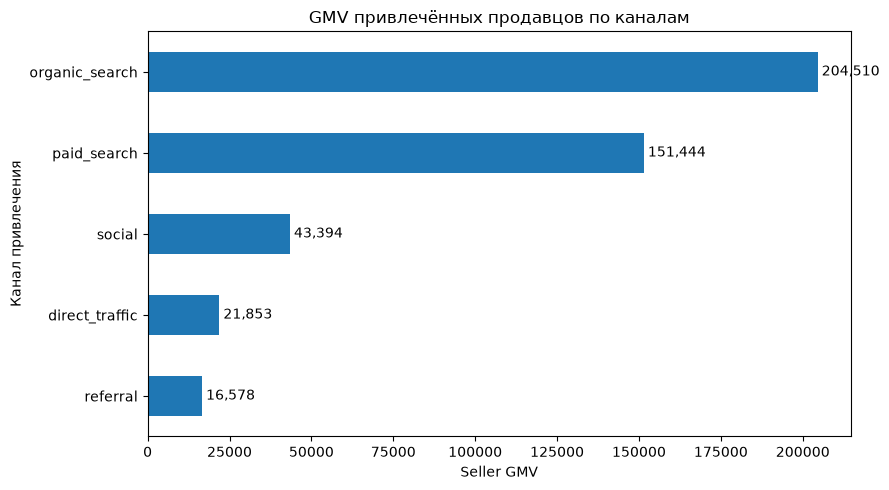

In [31]:
origin_gmv_plot = (
    actionable_origin_value
    .sort_values("total_seller_gmv")
)

ax = origin_gmv_plot.plot(
    x="origin_group",
    y="total_seller_gmv",
    kind="barh",
    figsize=(9, 5),
    legend=False,
)

ax.set_title("GMV привлечённых продавцов по каналам")
ax.set_xlabel("Seller GMV")
ax.set_ylabel("Канал привлечения")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:,.0f}"
            for value in origin_gmv_plot["total_seller_gmv"]
        ],
        padding=3,
    )

plt.tight_layout()
plt.show()

### Интерпретация seller GMV по каналам

Среди атрибутированных каналов наибольший совокупный GMV сформировали продавцы, привлечённые через `organic_search` — около 204,5 тыс., и `paid_search` — около 151,4 тыс.

Вместе эти два канала обеспечивают основную часть GMV привлечённых продавцов. При этом причины результата различаются:

- `organic_search` лидирует прежде всего за счёт большего объёма MQL и привлечённых продавцов;
- `paid_search` имеет меньший объём, но показывает более высокую активацию продавцов после закрытия сделки;
- `social` генерирует много лидов, однако его слабая конверсия ограничивает итоговый seller GMV;
- результаты `referral` выглядят перспективно по медианной ценности продавца, но основаны на небольшой выборке.

Следовательно, каналы нельзя оценивать только по конверсии `MQL → Closed Deal`. Для marketplace более полная оценка должна включать:

**MQL → Closed Deal → Seller with Orders → Seller GMV**

Без данных о маркетинговых расходах нельзя определить экономическую эффективность каналов или рассчитать CAC. Однако проведённый анализ позволяет сравнить их по объёму, конверсии, активации и последующей ценности продавцов.

In [32]:
funnel_seller_value = (
    seller_value
    .merge(
        mql[
            [
                "mql_id",
                "first_contact_date",
                "landing_page_id",
            ]
        ],
        on="mql_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        closed_deals[
            [
                "seller_id",
                "business_segment",
                "lead_type",
                "lead_behaviour_profile",
                "business_type",
            ]
        ],
        on="seller_id",
        how="left",
        validate="one_to_one",
    )
)

funnel_seller_value["days_to_close"] = (
    funnel_seller_value["won_date"]
    - funnel_seller_value["first_contact_date"]
).dt.total_seconds() / 86_400

funnel_seller_value["days_to_close_valid"] = (
    funnel_seller_value["days_to_close"]
    .where(funnel_seller_value["days_to_close"].ge(0))
)

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

output_path = (
    PROCESSED_DATA_DIR
    / "funnel_seller_value.csv"
)

funnel_seller_value.to_csv(
    output_path,
    index=False,
)

print(f"Файл сохранён: {output_path}")
print(f"Строк: {len(funnel_seller_value):,}")
print(
    "Уникальных seller_id:",
    funnel_seller_value["seller_id"].nunique(),
)

Файл сохранён: ..\data\processed\funnel_seller_value.csv
Строк: 842
Уникальных seller_id: 842


In [33]:
saved_funnel = pd.read_csv(
    output_path,
    parse_dates=[
        "first_contact_date",
        "won_date",
        "first_order_date",
        "last_order_date",
    ],
)

quality_check = pd.Series(
    {
        "rows": len(saved_funnel),
        "unique_sellers": saved_funnel["seller_id"].nunique(),
        "duplicate_sellers": saved_funnel["seller_id"].duplicated().sum(),
        "activated_sellers": saved_funnel[
            "has_post_acquisition_orders"
        ].sum(),
        "delivered_sellers": saved_funnel[
            "has_delivered_orders"
        ].sum(),
        "total_seller_gmv": saved_funnel["seller_gmv"].sum(),
    },
    name="value",
)

quality_check

rows                    842.00
unique_sellers          842.00
duplicate_sellers         0.00
activated_sellers       380.00
delivered_sellers       376.00
total_seller_gmv    664,858.00
Name: value, dtype: float64

## Итоги анализа Seller Marketing Funnel

В рамках анализа была построена расширенная воронка привлечения продавцов:

**MQL → Closed Deal → Seller with Orders → Seller GMV**

Основные результаты:

- из 8 000 маркетинговых лидов 842 завершились закрытой сделкой;
- конверсия `MQL → Closed Deal` составила 10,53%;
- 380 привлечённых продавцов получили хотя бы один заказ;
- 376 продавцов получили хотя бы один доставленный заказ;
- activation rate после закрытия сделки составил около 45%;
- медианное время до первого заказа — около 44 дней;
- медианный GMV продавца с доставленными заказами — 547,40;
- средний GMV такого продавца — 1 768,24, что указывает на сильную концентрацию GMV у небольшого числа крупных продавцов.

Среди атрибутированных каналов:

- `organic_search` привёл наибольшее количество активированных продавцов и сформировал наибольший совокупный seller GMV;
- `paid_search` показал более высокую активацию продавцов после сделки;
- `social` обеспечил большой объём MQL, но слабее конвертировал лиды в активных продавцов;
- `direct_traffic` показал высокую activation rate, но относительно низкую ценность продавцов;
- `referral` продемонстрировал высокий медианный GMV, однако результат основан на небольшой выборке.

Главный бизнес-вывод: канал привлечения продавцов нельзя оценивать только по конверсии в закрытую сделку. Для marketplace необходимо учитывать фактическую активацию продавцов и их последующий вклад в GMV.

### Ограничения анализа

- отсутствуют расходы на маркетинг, поэтому нельзя рассчитать настоящий CAC;
- seller GMV не является выручкой или прибылью маркетплейса;
- отсутствуют данные о комиссии, марже и себестоимости;
- продавцы имеют разный период наблюдения после привлечения;
- часть источников не атрибутирована и обозначена как `unknown` или пропущена;
- результаты небольших каналов необходимо интерпретировать осторожно.